<a href="https://colab.research.google.com/github/sathwikaguggilla/ParkShare/blob/main/Task1_Sales_Data_Analysis_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, desc, regexp_replace
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("Sales_Data_Analysis").getOrCreate()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


In [ ]:
df = spark.read.option("header", True).option("quote", '"').option("escape", '"').csv("SampleSuperstore.csv")

In [ ]:
df.show(5)
df.printSchema()

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+
|     1|CA-2017-152156|08/11/2017|11/11/2017|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset Col...|  261.96|
|     2|CA-2017-152156|08/11/2017|11/11/2017|  Second Class|   C

In [ ]:
from pyspark.sql.functions import col, regexp_replace

df = df.withColumn("Sales", regexp_replace("Sales", '[^0-9.]', ''))
df = df.withColumn("Sales", col("Sales").cast("double"))

df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+
|     1|CA-2017-152156|08/11/2017|11/11/2017|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset Col...|  261.96|
|     2|CA-2017-152156|08/11/2017|11/11/2017|  Second Class|   C

In [ ]:
from pyspark.sql.functions import sum, desc

print("Total Sales")
df.select(sum("Sales").alias("Total Sales")).show()

print("Sales by Category")
df.groupBy("Category").sum("Sales").show()

print("Sales by Region")
df.groupBy("Region").sum("Sales").show()

print("Top 10 Products by Sales")
df.groupBy("Product Name").sum("Sales").orderBy(desc("sum(Sales)")).show(10)

Total Sales
+-----------------+
|      Total Sales|
+-----------------+
|2261536.782699953|
+-----------------+

Sales by Category
+---------------+-----------------+
|       Category|       sum(Sales)|
+---------------+-----------------+
|Office Supplies|705422.3340000033|
|      Furniture|728658.5756999997|
|     Technology|827455.8729999965|
+---------------+-----------------+

Sales by Region
+-------+-----------------+
| Region|       sum(Sales)|
+-------+-----------------+
|  South|389151.4590000004|
|Central|492646.9132000005|
|   East|669518.7259999984|
|   West|710219.6845000003|
+-------+-----------------+

Top 10 Products by Sales
+--------------------+------------------+
|        Product Name|        sum(Sales)|
+--------------------+------------------+
|Canon imageCLASS ...|         61599.824|
|Fellowes PB500 El...|         27453.384|
|Cisco TelePresenc...|          22638.48|
|HON 5400 Series T...|         21870.576|
|GBC DocuBind TL30...|19823.479000000003|
|GBC Ibimaster

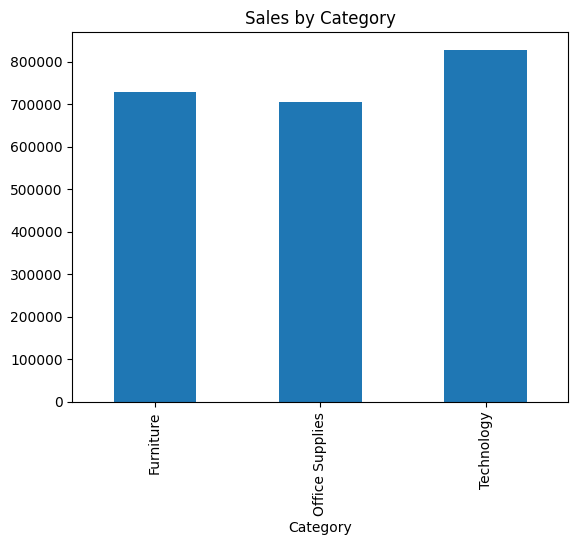

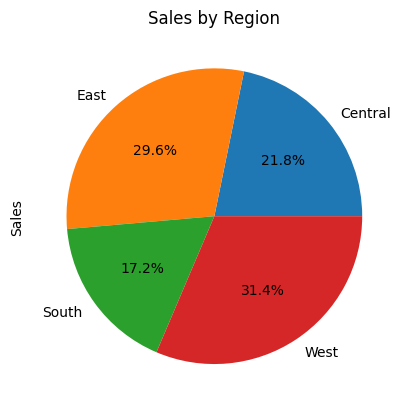

In [ ]:
import matplotlib.pyplot as plt

pdf = df.toPandas()

# Sales by Category
pdf.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

# Sales by Region
pdf.groupby("Region")["Sales"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Region")
plt.show()

# **Key Insights from Sales Data Analysis**:

 1. The dataset contains multiple product categories including Technology,
Furniture, and Office Supplies, providing a comprehensive view of retail sales performance.

 2. The total sales generated from the dataset are approximately $2.26 million, indicating strong overall business revenue.

 3. The Technology category records the highest sales among all categories, suggesting strong customer demand for technology-related products.

 4. Regional analysis shows that the West region contributes the highest share of sales compared to East, Central, and South regions.

 5. A small group of top-selling products contributes significantly to the overall sales, highlighting the importance of high-performing products in driving revenue.

# **Graph Visualization:**

The visualizations created using PySpark, Python, and Matplotlib help illustrate sales distribution across different categories and regions. These graphs provide a clear understanding of sales trends and highlight the key contributors to overall revenue.